In [1]:
from viz_helpers import *

# Nonlinear XOR dataset

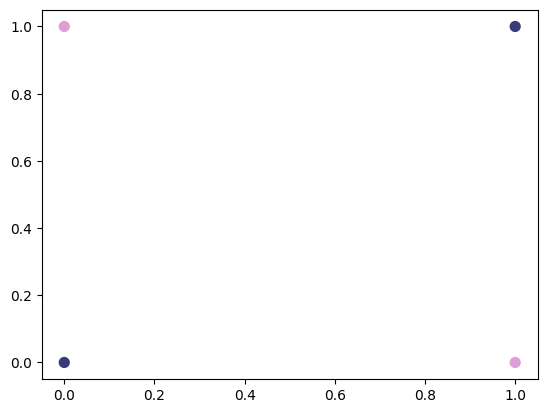

In [2]:
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

y = np.array([0, 1, 1, 0])

plot_2d_clf_problem(X, y)

# Training binary classification model

===== EPOCH : 0 ===== LOSS : 0.69715 =====
===== EPOCH : 500 ===== LOSS : 0.69236 =====
===== EPOCH : 1000 ===== LOSS : 0.00600 =====
===== EPOCH : 1500 ===== LOSS : 0.00262 =====
===== EPOCH : 2000 ===== LOSS : 0.00167 =====
Accuracy: 1.0


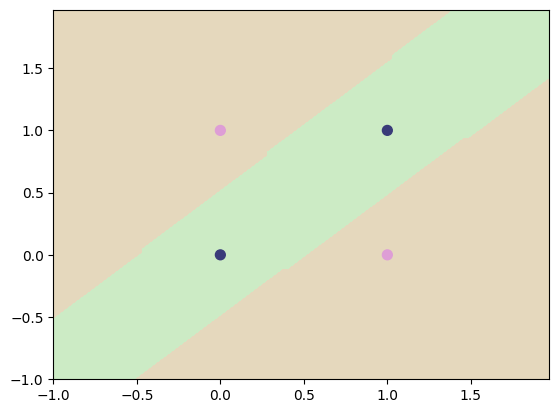

In [3]:
from dlfs.loss import BCE_Loss
from dlfs.optimizers import Optimizer_SGD, Optimizer_Adam
from dlfs.layers import DenseLayer
from dlfs.activation import Sigmoid
from dlfs.model import SequentialModel

layers = [DenseLayer(2, 2),
          Sigmoid(),
          DenseLayer(2, 1),
          Sigmoid()]

model = SequentialModel(layers=layers, loss_function=BCE_Loss(), optimizer=Optimizer_SGD(learning_rate=5e-1, momentum=0.5))

model.train(X, y.reshape(-1, 1), epochs=2000, print_every=500)
print(f'Accuracy: {np.mean(y.reshape(-1, 1) == np.round(model.predict(X)))}')
plot_2d_clf_problem(X, y, lambda x: model.predict(x) > 0.5)

# Extract each layer's output

In [4]:
model.forward(X)

Z1 = model.wrapper.layers[0].output.copy() # first dense layer
A1 = model.wrapper.layers[1].output.copy() # first dense + sigmoid
Z2 = model.wrapper.layers[2].output.copy() # second dense
A2 = model.wrapper.layers[3].output.copy() # second dense + sigmoid

# Plotting first linear transformation

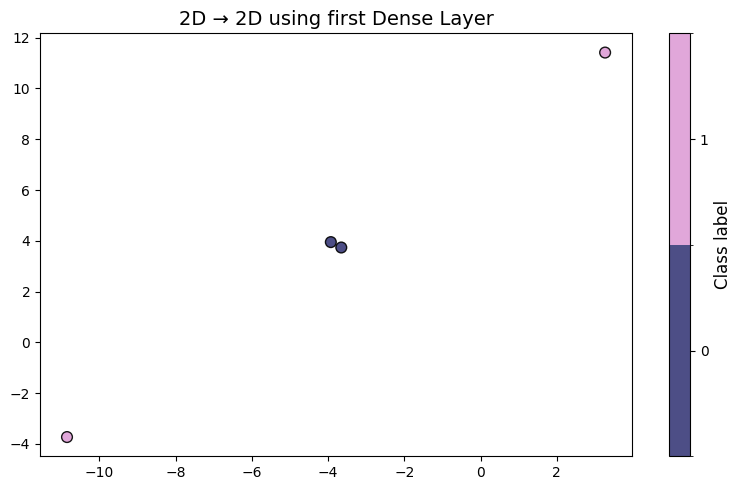

In [5]:
plot_2d_output(Z1, y, "2D → 2D using first Dense Layer")

# Plotting first linear transformation and first activation

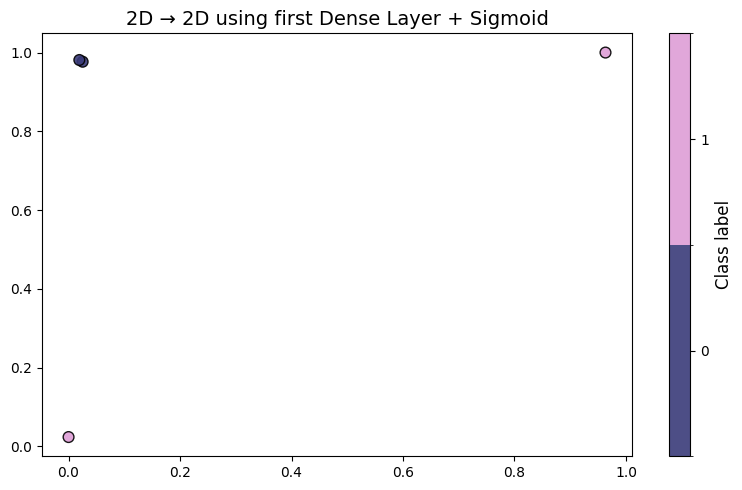

In [6]:
plot_2d_output(A1, y, "2D → 2D using first Dense Layer + Sigmoid")

# Plotting second linear transformation

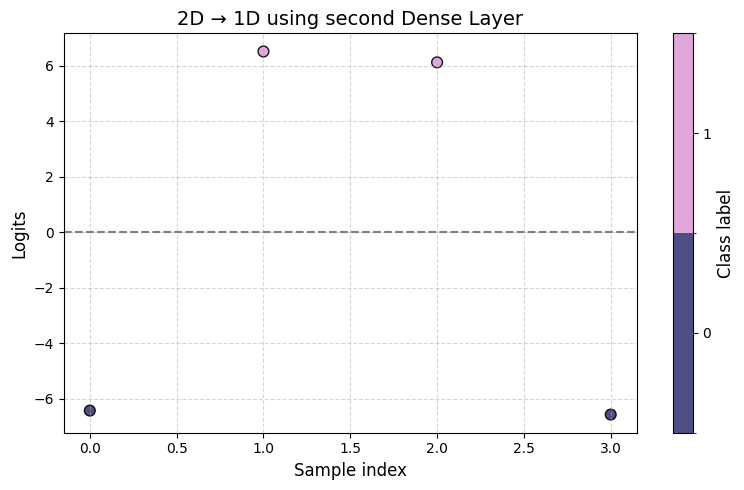

In [7]:
plot_1d_output(Z2, y, "2D → 1D using second Dense Layer", logits=True)

# Plotting second linear transformation and second activation

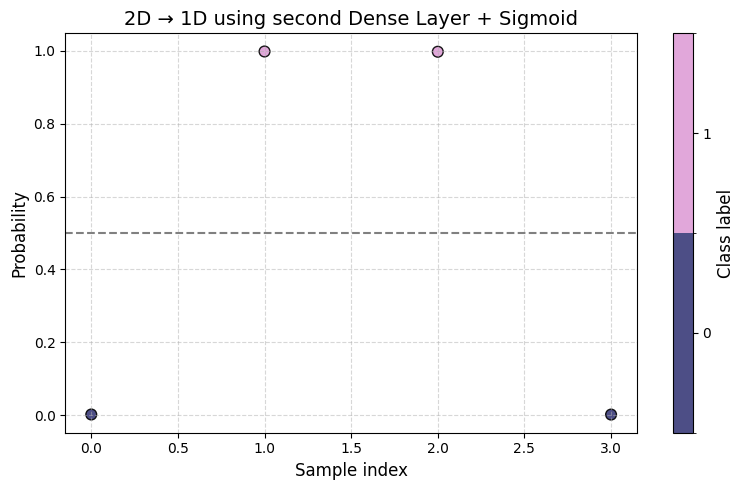

In [8]:
plot_1d_output(A2, y, "2D → 1D using second Dense Layer + Sigmoid", logits=False)